# Lattes baseline analysis

This notebook inspects deterministic CSV files produced by `analyze_lattes.py`. It does not read raw JSONL files, traces, or expected paper values, and it does not recompute the discarded Pareto analysis.


In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'experiments' / 'lattes').exists():
    ROOT = ROOT.parent.parent

ANALYSIS_DIR = ROOT / 'experiments' / 'lattes' / 'baseline_001' / 'derived' / 'analysis'
required = [
    'lattes_trials.csv',
    'lattes_summary_by_configuration.csv',
    'lattes_summary_by_model.csv',
    'lattes_summary_by_question.csv',
    'lattes_summary_by_curriculum.csv',
    'lattes_summary_by_tag.csv',
    'lattes_summary_by_judge.csv',
    'table-5.csv',
    'table-6.csv',
    'table-7.csv',
    'lattes_analysis_manifest.json',
]
missing = [name for name in required if not (ANALYSIS_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(
        'Missing derived analysis files: ' + ', '.join(missing) + '\n'
        'Run: just lattes-analyze'
    )

manifest = json.loads((ANALYSIS_DIR / 'lattes_analysis_manifest.json').read_text())
manifest


{'sourceDirectory': '/home/michel/repos/doutorado/llmcontextbench-experiments/experiments/lattes/baseline_001',
 'sourceArtifacts': ['queries.jsonl',
  'answers.jsonl',
  'judge_votes.jsonl',
  'traces/queries/'],
 'runCount': 1200,
 'voteCount': 3600,
 'configurations': {'Func.': 240,
  'I-HTML': 240,
  'I-JSON': 240,
  'L-MCP': 240,
  'R-MCP': 240},
 'models': ['gemini-2.5-flash',
  'gemini-2.5-flash-lite',
  'gpt-5.4-mini',
  'gpt-5.4-nano'],
 'questions': ['q_field',
  'q_projfit_2',
  'q_indexed',
  'q_en',
  'q_techprod',
  'q_phd',
  'q_admin',
  'q_pubyear',
  'q_advpub',
  'q_coauth',
  'q_tcc5y',
  'q_sup'],
 'instances': ['3457219624656691',
  '3957046121364560',
  '4093653182381054',
  '5123602572479168',
  '5521922960404236'],
 'paperTables': ['table-5.csv', 'table-6.csv', 'table-7.csv'],
 'paperFigures': ['figure-3a-latency-violin',
  'figure-3b-question-accuracy-heatmap',
  'figure-3-combined'],
 'note': 'All numerical outputs are derived directly from preserved experime

In [2]:
trials = pd.read_csv(ANALYSIS_DIR / 'lattes_trials.csv')
summary_configuration = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_configuration.csv')
summary_model = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_model.csv')
summary_question = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_question.csv')
summary_curriculum = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_curriculum.csv')
summary_tag = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_tag.csv')
summary_judge = pd.read_csv(ANALYSIS_DIR / 'lattes_summary_by_judge.csv')
table_5 = pd.read_csv(ANALYSIS_DIR / 'table-5.csv')
table_6 = pd.read_csv(ANALYSIS_DIR / 'table-6.csv')
table_7 = pd.read_csv(ANALYSIS_DIR / 'table-7.csv')


## Research paper Table 5


In [3]:
table_5


,Configuration,Strategy,Runs,Maj.,Unan.,Tok./run,Tok./Maj.,Tok./Unan.,Sec.,Obs. calls
0,I-HTML,Inline HTML,240,42.1,26.2,79.3k,188.4k,302.0k,4.09,0.00
1,I-JSON,Inline JSON,240,45.8,24.6,70.6k,153.9k,287.0k,4.01,0.00
2,Func.,Local function calling,240,35.0,18.8,11.7k,33.5k,62.6k,4.61,1.23
3,L-MCP,Local MCP,240,35.4,17.5,12.6k,35.4k,71.7k,4.45,1.29
4,R-MCP,Remote MCP,240,35.8,14.6,9.0k,25.1k,61.7k,5.99,1.15


## Research paper Table 6


In [4]:
table_6


,Family,Model,Configuration,Maj.,Unan.,Tok.,Sec.,Calls
0,OpenAI,GPT-Nano,I-HTML,48.3,30.0,78.7k,7.62,0.00
1,OpenAI,GPT-Nano,I-JSON,60.0,30.0,67.9k,13.87,0.00
2,OpenAI,GPT-Nano,Func.,53.3,33.3,16.1k,6.58,1.42
3,OpenAI,GPT-Nano,L-MCP,43.3,28.3,18.6k,5.56,1.40
4,OpenAI,GPT-Nano,R-MCP,48.3,28.3,17.4k,7.93,1.35
5,OpenAI,GPT-Mini,I-HTML,53.3,28.3,78.8k,3.57,0.00
6,OpenAI,GPT-Mini,I-JSON,50.0,23.3,68.1k,3.99,0.00
7,OpenAI,GPT-Mini,Func.,45.0,25.0,20.2k,5.77,1.83
8,OpenAI,GPT-Mini,L-MCP,53.3,30.0,20.5k,6.01,1.88
9,OpenAI,GPT-Mini,R-MCP,51.7,20.0,17.2k,8.69,1.62


## Research paper Table 7


In [5]:
table_7


,Question,Tags,Maj.,Unan.,Full dis.,Calls,Dominant difficulty
0,q_field,"inferential, ranking",87.0,58.0,1.0,0.79,broad profile synthesis
1,q_projfit_2,"inferential, cross-block",62.0,32.0,2.0,1.87,cross-section project matching
2,q_indexed,"weak-data, quantitative",58.0,23.0,11.0,0.42,weak evidence and count interpretation
3,q_en,factual,52.0,52.0,0.0,0.34,simple lookup; mostly stable
4,q_techprod,"weak-data, quantitative",48.0,29.0,3.0,0.60,weakly structured technical output
5,q_phd,"factual, temporal",45.0,23.0,0.0,0.58,temporal education lookup
6,q_admin,factual,38.0,19.0,0.0,1.05,administrative-role evidence
7,q_pubyear,"weak-data, temporal, ranking",34.0,5.0,4.0,0.38,temporal publication ranking
8,q_advpub,"inferential, cross-block, quantitative, matching",30.0,2.0,5.0,0.72,supervision–publication matching
9,q_coauth,"inferential, quantitative, ranking, matching",7.0,0.0,29.0,0.36,coauthor aggregation and ranking


## Additional derived summaries

The following cells expose normalized intermediate summaries for inspection. They are not alternate sources for Tables 5–7.


In [6]:
summary_configuration.style.format(precision=2)


,Config,N,Maj.,Unan.,Tok./T,Tok./M,Tok./U,Sec.,Calls,MajorityCount,UnanimousCount
0,I-HTML,240,42.08,26.25,79282.36,188393.73,302028.05,4.09,0.00,101,63
1,I-JSON,240,45.83,24.58,70557.73,153944.15,287014.51,4.01,0.00,110,59
2,Func.,240,35.00,18.75,11728.32,33509.48,62551.02,4.61,1.23,84,45
3,L-MCP,240,35.42,17.50,12550.37,35436.33,71716.38,4.45,1.29,85,42
4,R-MCP,240,35.83,14.58,9003.57,25126.24,61738.77,5.99,1.15,86,35


In [7]:
summary_model.style.format(precision=2)


,model,configuration,N,Majority,Unanimous,MeanTokens,MedianSec,MeanCalls
0,gemini-2.5-flash,Func.,60,26.67,11.67,6140.92,4.09,0.78
1,gemini-2.5-flash,I-HTML,60,33.33,23.33,80530.98,5.42,0.00
2,gemini-2.5-flash,I-JSON,60,40.00,26.67,73658.62,5.40,0.00
3,gemini-2.5-flash,L-MCP,60,23.33,6.67,6426.85,3.68,0.82
4,gemini-2.5-flash,R-MCP,60,28.33,6.67,1112.32,4.94,0.85
5,gemini-2.5-flash-lite,Func.,60,15.00,5.00,4445.93,2.72,0.87
6,gemini-2.5-flash-lite,I-HTML,60,33.33,23.33,79151.52,3.22,0.00
7,gemini-2.5-flash-lite,I-JSON,60,33.33,18.33,72502.12,2.81,0.00
8,gemini-2.5-flash-lite,L-MCP,60,21.67,5.00,4659.43,2.92,1.05
9,gemini-2.5-flash-lite,R-MCP,60,15.00,3.33,312.00,3.25,0.78


In [8]:
summary_question.style.format(precision=2)


,question_id,configuration,N,Majority,Unanimous,MeanTokens,MedianSec,MeanCalls
0,q_admin,Func.,20,35.00,20.00,14618.20,6.01,2.00
1,q_admin,I-HTML,20,30.00,15.00,79332.40,4.49,0.00
2,q_admin,I-JSON,20,55.00,30.00,69688.35,4.46,0.00
3,q_admin,L-MCP,20,35.00,15.00,15048.75,6.29,1.80
4,q_admin,R-MCP,20,35.00,15.00,8627.20,7.25,1.45
5,q_advpub,Func.,20,15.00,0.00,23426.85,4.69,1.10
6,q_advpub,I-HTML,20,25.00,10.00,80013.75,3.59,0.00
7,q_advpub,I-JSON,20,50.00,0.00,69786.30,3.99,0.00
8,q_advpub,L-MCP,20,35.00,0.00,28664.95,4.85,1.20
9,q_advpub,R-MCP,20,25.00,0.00,24712.25,7.71,1.30


In [9]:
summary_curriculum.style.format(precision=2)


,instance_id,configuration,N,Majority,Unanimous,MeanTokens,MedianSec,MeanCalls
0,3457219624656691,Func.,48,31.25,12.50,16944.17,4.98,1.17
1,3457219624656691,I-HTML,48,50.00,31.25,109214.60,4.31,0.00
2,3457219624656691,I-JSON,48,47.92,25.00,97169.08,3.91,0.00
3,3457219624656691,L-MCP,48,27.08,12.50,16871.48,4.60,1.25
4,3457219624656691,R-MCP,48,25.00,8.33,12412.62,7.20,1.21
5,3957046121364560,Func.,48,35.42,16.67,7359.58,4.52,1.25
6,3957046121364560,I-HTML,48,43.75,33.33,37916.65,2.95,0.00
7,3957046121364560,I-JSON,48,50.00,27.08,44367.00,3.63,0.00
8,3957046121364560,L-MCP,48,39.58,16.67,8418.06,4.66,1.35
9,3957046121364560,R-MCP,48,41.67,12.50,6296.35,6.32,1.23


In [10]:
summary_tag.style.format(precision=2)


,question_tags,configuration,N,Majority,Unanimous
0,cross-block,Func.,40,35.00,17.50
1,cross-block,I-HTML,40,47.50,17.50
2,cross-block,I-JSON,40,50.00,10.00
3,cross-block,L-MCP,40,50.00,20.00
4,cross-block,R-MCP,40,47.50,20.00
5,factual,Func.,100,25.00,18.00
6,factual,I-HTML,100,33.00,25.00
7,factual,I-JSON,100,38.00,27.00
8,factual,L-MCP,100,26.00,17.00
9,factual,R-MCP,100,18.00,8.00


In [11]:
summary_judge.style.format(precision=2)


,judge_id,judge_provider,judge_model,configuration,N,CorrectnessMeets,CompletenessMeets,BothMeet,MeanJudgeTokens,MedianJudgeSec
0,juiz-claude,anthropic,claude-sonnet-4-6,Func.,240,39.17,34.58,28.33,740.98,4.48
1,juiz-claude,anthropic,claude-sonnet-4-6,I-HTML,240,51.67,42.08,33.33,776.58,4.60
2,juiz-claude,anthropic,claude-sonnet-4-6,I-JSON,240,54.58,40.83,34.17,752.34,4.50
3,juiz-claude,anthropic,claude-sonnet-4-6,L-MCP,240,41.25,32.08,26.25,747.94,4.50
4,juiz-claude,anthropic,claude-sonnet-4-6,R-MCP,240,36.67,31.25,26.67,748.82,4.51
5,juiz-gemini,google,gemini-3.1-flash-lite-preview,Func.,240,62.08,62.50,58.33,12035.63,2.06
6,juiz-gemini,google,gemini-3.1-flash-lite-preview,I-HTML,240,75.42,72.08,67.50,12056.95,2.11
7,juiz-gemini,google,gemini-3.1-flash-lite-preview,I-JSON,240,76.67,77.08,72.50,12035.60,2.06
8,juiz-gemini,google,gemini-3.1-flash-lite-preview,L-MCP,240,63.75,63.33,59.58,12043.82,2.10
9,juiz-gemini,google,gemini-3.1-flash-lite-preview,R-MCP,240,58.33,60.00,56.25,12046.08,2.24


## Trial-level inspection


In [12]:
trials[[
    'configuration', 'question_id', 'model', 'majority_correct',
    'unanimous_correct', 'query_total_tokens',
    'query_duration_sec', 'observed_calls'
]].head()


,configuration,question_id,model,majority_correct,unanimous_correct,query_total_tokens,query_duration_sec,observed_calls
0,Func.,q_admin,gemini-2.5-flash-lite,False,False,12113.0,11.921,2
1,Func.,q_admin,gemini-2.5-flash,False,False,1638.0,4.588,0
2,Func.,q_admin,gpt-5.4-nano,True,False,15020.0,7.154,2
3,Func.,q_admin,gpt-5.4-mini,False,False,16627.0,7.076,3
4,Func.,q_admin,gemini-2.5-flash-lite,False,False,3347.0,6.203,2


## Figure 3

The figures below are rendered with the exact same drawing functions used by `generate_figures.py` (`load_analysis`, `draw_latency_violin`, `draw_accuracy_heatmap`). The script and this notebook therefore never diverge in how the plots are built — only in where the output goes (a file on disk vs. inline display).

In [13]:
import sys

import matplotlib.pyplot as plt

LATTES_DIR = ROOT / "experiments" / "lattes"
if str(LATTES_DIR) not in sys.path:
    sys.path.insert(0, str(LATTES_DIR))

import generate_figures as gf

gf_trials, gf_questions, gf_configurations = gf.load_analysis(ANALYSIS_DIR)
gf_questions, gf_configurations

(['q_field',
  'q_projfit_2',
  'q_indexed',
  'q_en',
  'q_techprod',
  'q_phd',
  'q_admin',
  'q_pubyear',
  'q_advpub',
  'q_coauth',
  'q_tcc5y',
  'q_sup'],
 ['I-HTML', 'I-JSON', 'Func.', 'L-MCP', 'R-MCP'])

### Figure 3a — query latency by configuration

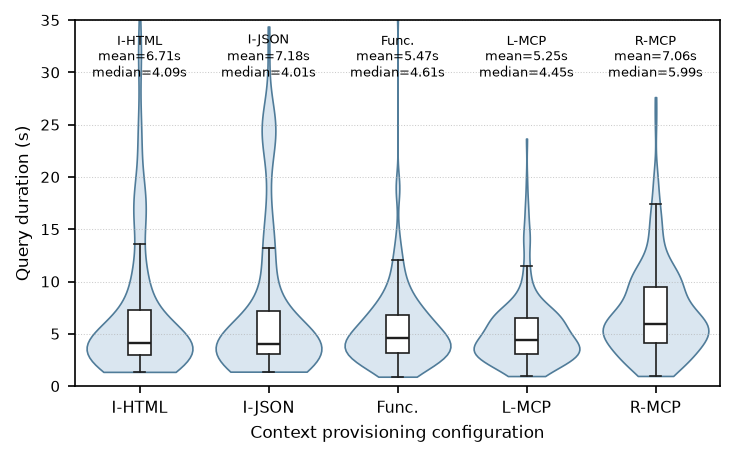

In [14]:
fig, ax = plt.subplots(figsize=(5.0, 3.15), dpi=150)
gf.draw_latency_violin(ax, gf_trials, gf_configurations)
fig.tight_layout()
plt.show()

### Figure 3b — question-by-configuration majority-accuracy heatmap

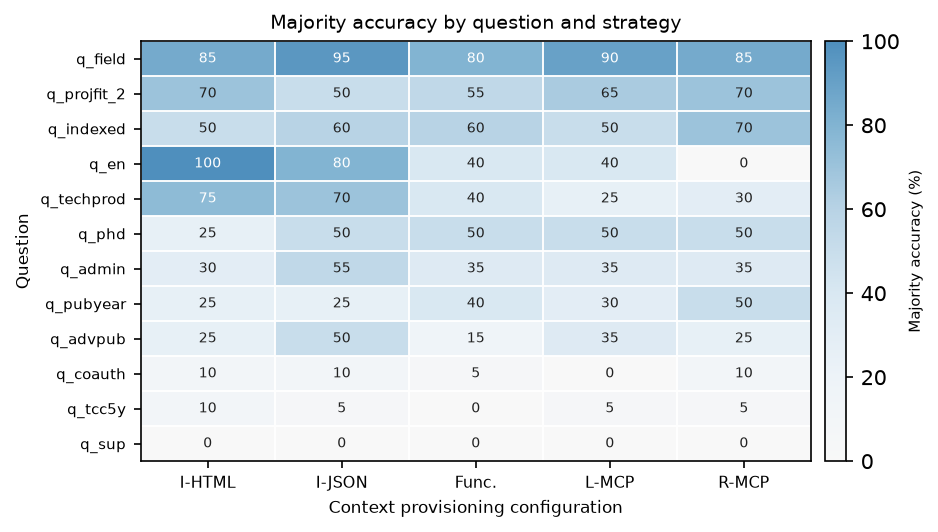

In [15]:
fig, ax = plt.subplots(figsize=(6.35, 3.65), dpi=150)
image = gf.draw_accuracy_heatmap(ax, gf_trials, gf_questions, gf_configurations)
colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("Majority accuracy (%)", fontsize=7.4)
fig.tight_layout()
plt.show()

### Figure 3 — combined

Renders both panels side by side, matching `generate_figures.py --only combined`.

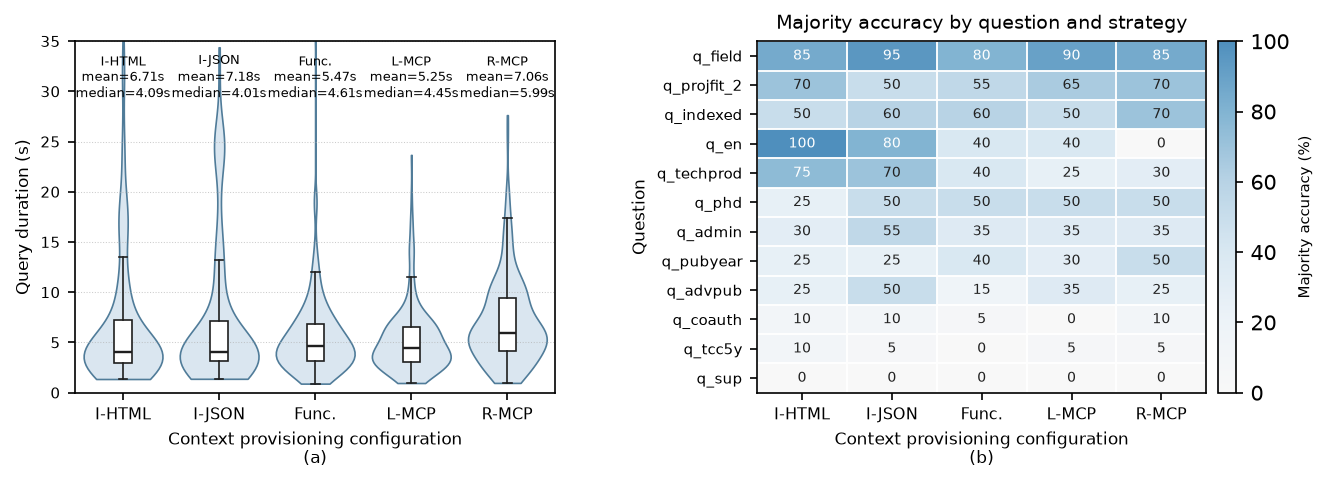

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.55), dpi=150)
gf.draw_latency_violin(axes[0], gf_trials, gf_configurations)
image = gf.draw_accuracy_heatmap(axes[1], gf_trials, gf_questions, gf_configurations)
axes[0].text(0.5, -0.20, "(a)", transform=axes[0].transAxes, ha="center", fontsize=8)
axes[1].text(0.5, -0.20, "(b)", transform=axes[1].transAxes, ha="center", fontsize=8)
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.040, pad=0.025)
colorbar.set_label("Majority accuracy (%)", fontsize=7.2)
fig.subplots_adjust(wspace=0.42, bottom=0.22)
plt.show()